# 🚗 Car Price Prediction using Machine Learning

## Introduction

Car price prediction is one of the most common real-world machine learning applications used by car dealerships, automobile companies, and online vehicle selling platforms. The price of a used car depends on several factors such as its age, current market price, fuel type, transmission type, number of previous owners, and distance driven.

In this project, we will build a Machine Learning Regression model that predicts the selling price of a car based on its features. The project covers the complete machine learning workflow, including data preprocessing, exploratory data analysis (EDA), feature engineering, model training, evaluation, and prediction.

By comparing different regression algorithms, we will identify the model that provides the most accurate car price predictions.

## Objective

The main objectives of this project are:

- To analyze the car price dataset.
- To clean and preprocess the data.
- To perform exploratory data analysis (EDA).
- To engineer useful features for better prediction.
- To train multiple Machine Learning regression models.
- To compare model performance using evaluation metrics.
- To predict the selling price of a car accurately.

# Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

# Save Model
import joblib

# Load the Dataset

In [2]:
# Read the CSV file
df = pd.read_csv("car data.csv")

# Display first five rows
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
# Display the number of rows and columns
print("Shape of Dataset:", df.shape)

# Display rows and columns separately
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Shape of Dataset: (301, 9)
Number of Rows: 301
Number of Columns: 9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


* The dataset contains 301 records and 9 features, including both numerical and categorical data.
* There are no missing values.
* The dataset includes important car attributes such as year, selling price, present price, fuel type, transmission, ownership, and kilometers driven, which are useful for predicting car prices.

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


* The dataset contains 301 car records with information about car price, manufacturing year, ownership, and other important features.
* Most cars were manufactured around 2013, with the oldest car from 2003 and the newest from 2018.
* The average selling price is 4.66 lakhs, and most cars have 0 previous owners, making ownership an important factor in price prediction.

In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


There No missing values are present in the dataset.

In [10]:
print(df.duplicated().sum())


2


* The dataset contains 2 duplicate records.
* Duplicate rows can affect the accuracy of the model.
* These duplicate records should be removed before further analysis.

In [11]:
df.drop_duplicates(inplace=True)

# Feature Engineering

In [12]:
df["Car_Age"] = 2026 - df["Year"]

df.drop("Year",axis=1,inplace=True)

In [13]:
df["Brand"] = df["Car_Name"].apply(lambda x:x.split()[0])

df.drop("Car_Name",axis=1,inplace=True)

* Created a new feature Car_Age by subtracting the manufacturing year from 2026 to represent the car's age.
* Removed the Year column since its information is now captured in Car_Age.
* Extracted the car brand from the Car_Name column and then dropped the original Car_Name column to simplify the dataset.

In [14]:
print(df.shape)

(299, 9)


In [17]:
df.dtypes

,0
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64
Car_Age,int64
Brand,object


#EDA

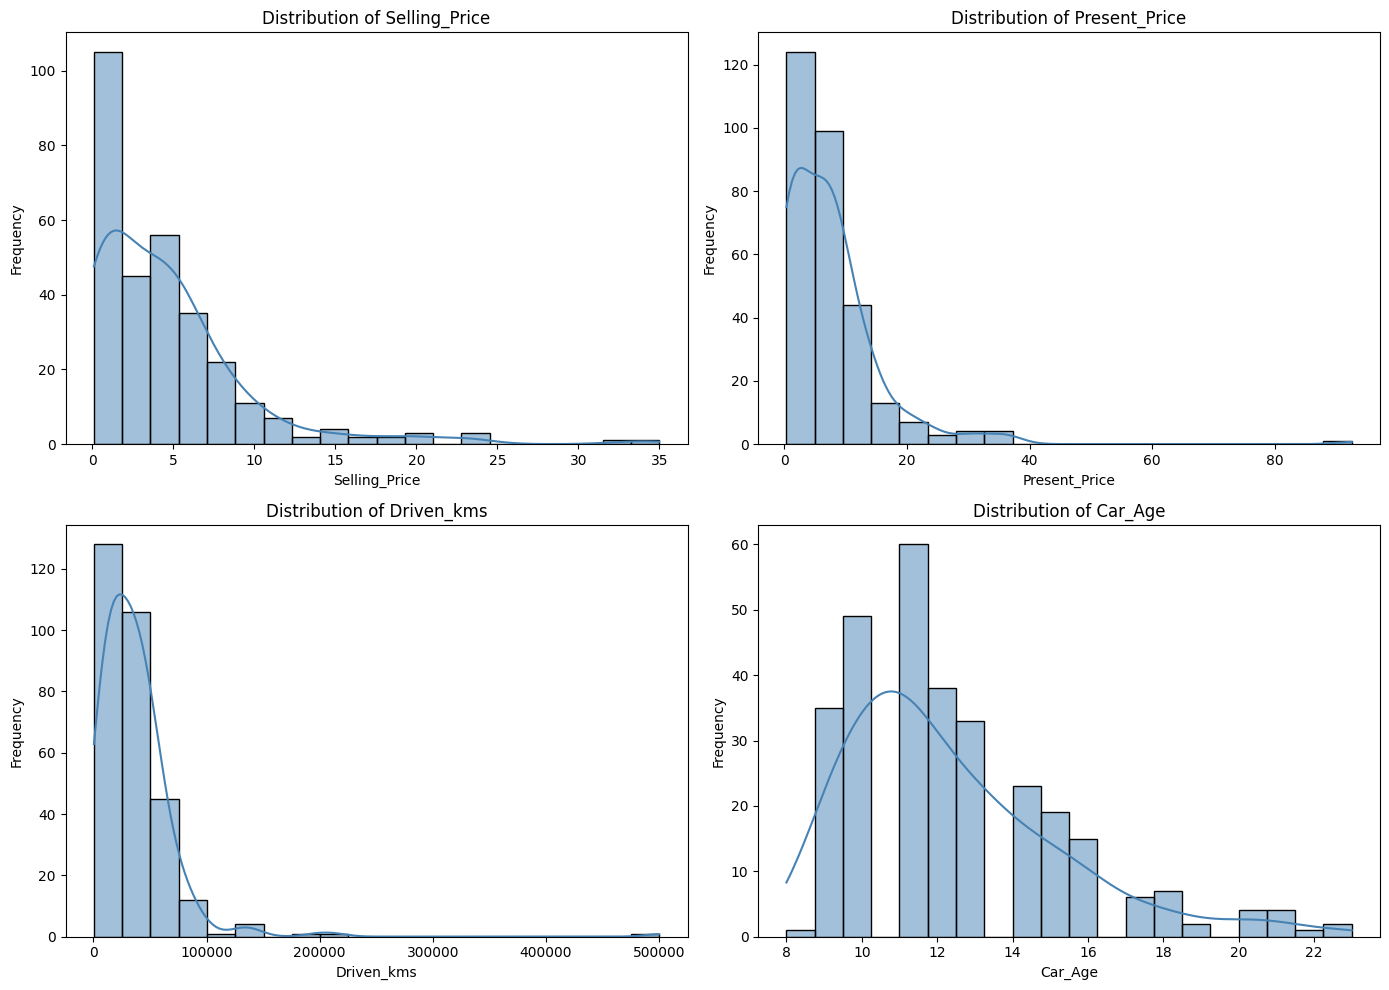

In [55]:
numerical_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Car_Age"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, bins=20, color="steelblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

* Most cars have low selling price, present price, and driven kilometers, while only a few cars have very high values.
* The numerical features are right-skewed, indicating that higher values occur less frequently.
* The Car_Age distribution shows that most cars are 10 to 13 years old, with fewer older vehicles.

## Countplot

/tmp/ipykernel_4708/2510354894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")
/tmp/ipykernel_4708/2510354894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")
/tmp/ipykernel_4708/2510354894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette="Set2")
/tmp/ipykernel_4708/2510354894.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False

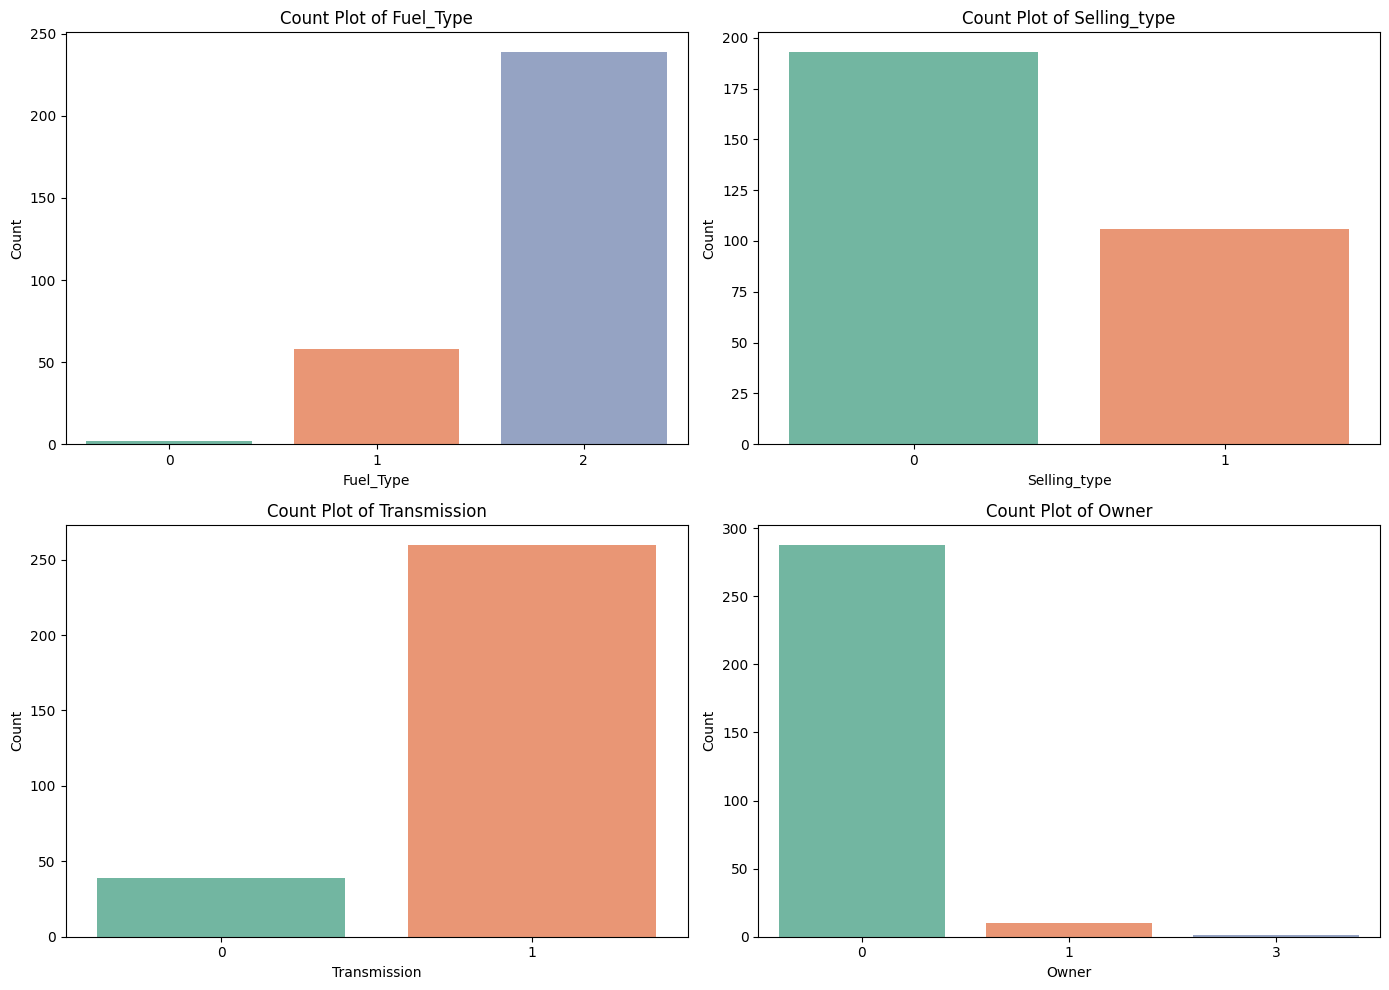

In [53]:
categorical_cols = ["Fuel_Type", "Selling_type", "Transmission", "Owner"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, data=df, palette="Set2")
    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

* Most cars use Petrol fuel, while Diesel cars are fewer and CNG cars are very rare.
* The dataset contains more cars sold by Dealers than by Individual sellers.
* Most cars have Manual transmission and 0 previous owners, indicating that first-owner manual cars are the most common.

## Boxplots

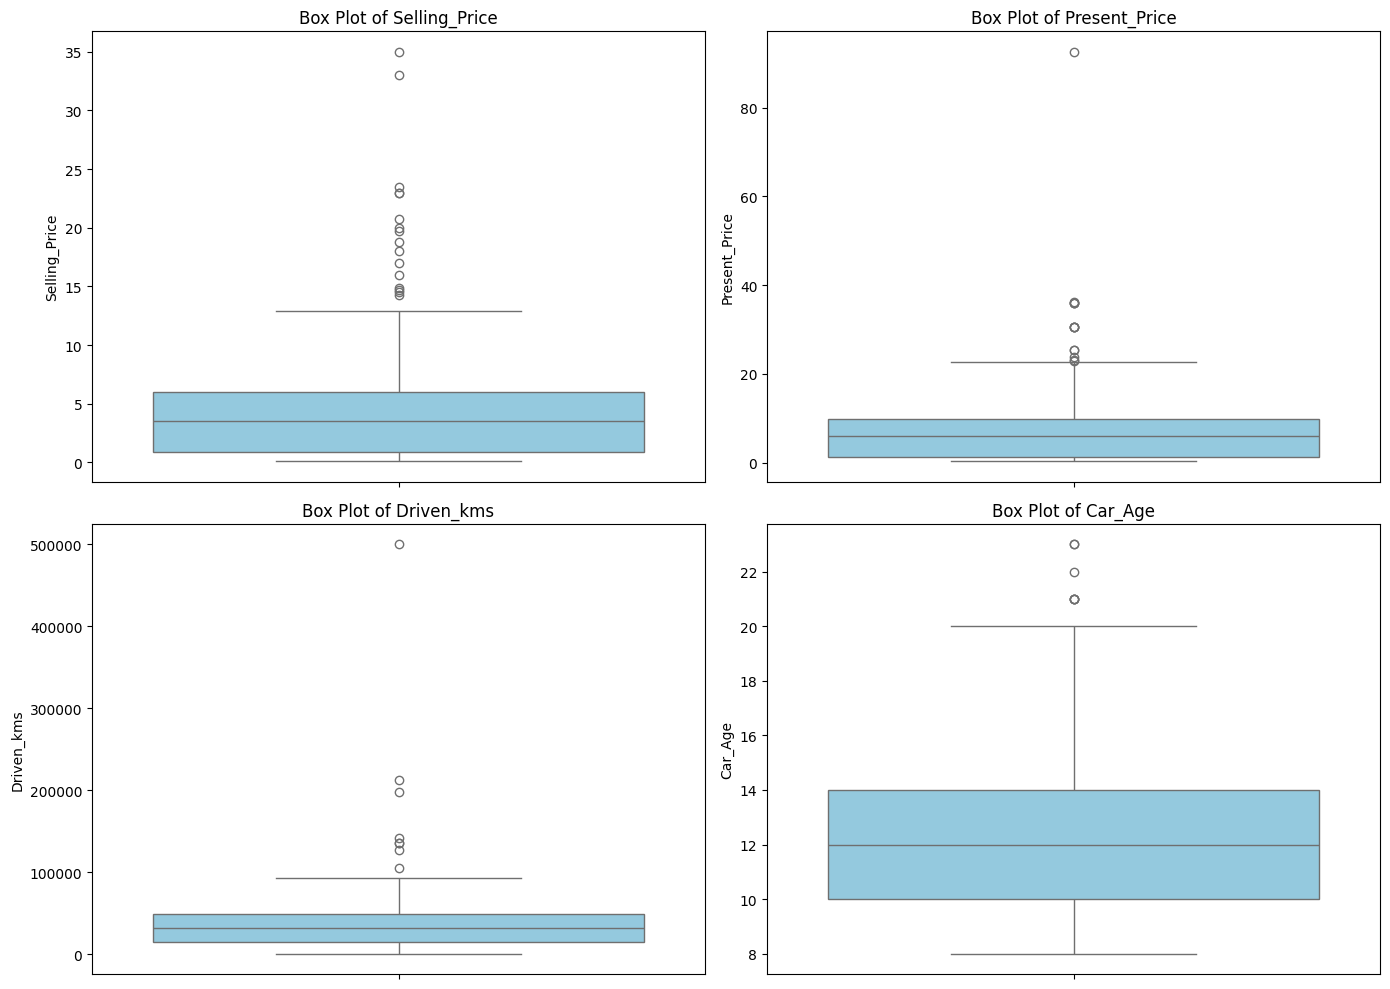

In [54]:
numerical_cols = ["Selling_Price", "Present_Price", "Driven_kms", "Car_Age"]

plt.figure(figsize=(14, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Box Plot of {col}")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

* Selling Price, Present Price, and Driven_kms contain several outliers, indicating a few cars have very high values.
* Car_Age has only a few outliers, while most cars are between 10 and 14 years old.
* The majority of data points are concentrated within the box, showing that most cars have similar values with only a few extreme cases.

# Encoding

In [34]:
le=LabelEncoder()

categorical=df.select_dtypes(include="object").columns

for col in categorical:
    df[col]=le.fit_transform(df[col])


## Correlation Heatmap

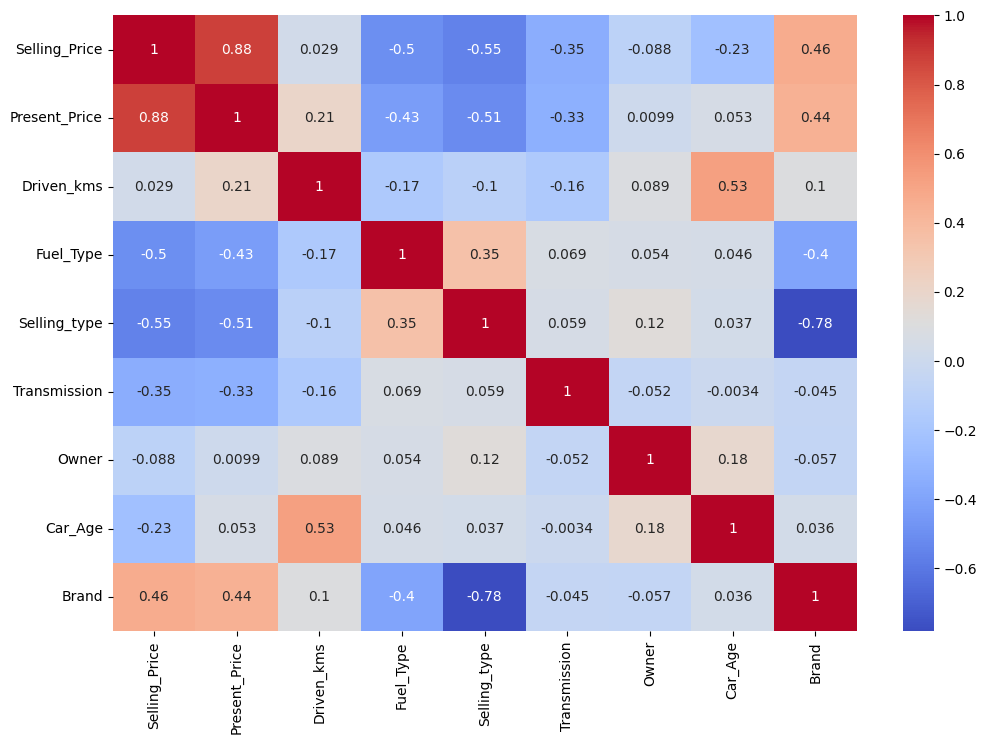

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

* Selling_Price has a strong positive correlation (0.88) with Present_Price, making it the most important feature for price prediction.
* Car_Age has a negative correlation (-0.23) with Selling_Price, indicating that older cars generally have lower selling prices.
* Most other features show weak to moderate correlations, meaning they have less influence on the selling price compared to Present_Price.

## Features

In [36]:

X=df.drop("Selling_Price",axis=1)

y=df["Selling_Price"]

# Train Test Split

In [37]:

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

print(X_train.shape)
print(X_test.shape)

(239, 8)
(60, 8)


#Model

In [38]:
models={

"Linear Regression":LinearRegression(),

"Decision Tree":DecisionTreeRegressor(random_state=42),

"Random Forest":RandomForestRegressor(random_state=42),

"Gradient Boosting":GradientBoostingRegressor(random_state=42)

}

In [56]:
results=[]

for name,model in models.items():

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)

    mae=mean_absolute_error(y_test,prediction)

    mse=mean_squared_error(y_test,prediction)

    rmse=np.sqrt(mse)

    r2=r2_score(y_test,prediction)

    results.append([name,mae,mse,rmse,r2])

    print("="*60)
    print(name)
    print("MAE :",mae)
    print("MSE :",mse)
    print("RMSE :",rmse)
    print("R2 Score :",r2)


Linear Regression
MAE : 1.5624008730945378
MSE : 6.75692916870858
RMSE : 2.599409388439724
R2 Score : 0.7378318231332539
Decision Tree
MAE : 1.0658333333333332
MSE : 4.128521666666667
RMSE : 2.031876390597289
R2 Score : 0.8398137716882819
Random Forest
MAE : 1.285793333333334
MSE : 9.93333926633334
RMSE : 3.151720048851633
R2 Score : 0.6145874286038724
Gradient Boosting
MAE : 1.2082862888727455
MSE : 7.446436136709095
RMSE : 2.7288158854545492
R2 Score : 0.71107902164249


* Decision Tree performed the best with the highest R² Score (0.84) and the lowest MAE (1.07) and RMSE (2.03).
* Linear Regression achieved a good performance with an R² Score of 0.74, but was less accurate than the Decision Tree model.
* Random Forest and Gradient Boosting showed lower performance, with Random Forest having the lowest R² Score (0.61) among all models.

In [42]:
comparison=pd.DataFrame(
results,
columns=[
"Model",
"MAE",
"MSE",
"RMSE",
"R2 Score"
])

print(comparison)

               Model       MAE       MSE      RMSE  R2 Score
0  Linear Regression  1.562401  6.756929  2.599409  0.737832
1      Decision Tree  1.065833  4.128522  2.031876  0.839814
2      Random Forest  1.285793  9.933339  3.151720  0.614587
3  Gradient Boosting  1.208286  7.446436  2.728816  0.711079


## Best Model

In [43]:
best_model=RandomForestRegressor(random_state=42)

best_model.fit(X_train,y_train)

prediction=best_model.predict(X_test)

In [52]:
print(prediction)


[7.311]


## Actual vs Predicted

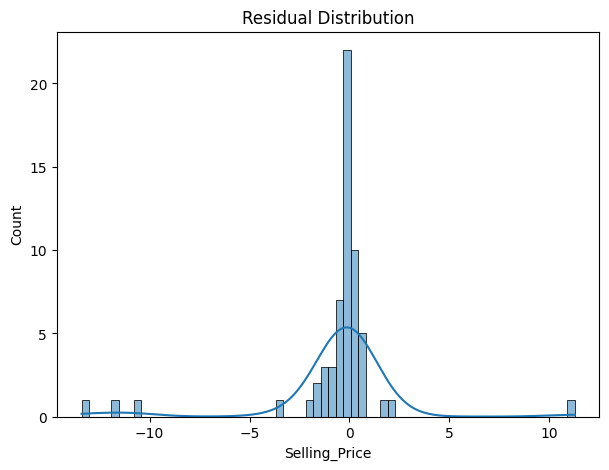

In [45]:

residual=y_test-prediction

plt.figure(figsize=(7,5))

sns.histplot(residual,kde=True)

plt.title("Residual Distribution")

plt.show()

* Most residual values are close to 0, indicating that the model's predictions are generally accurate.
* The residuals are approximately centered around zero, showing no major prediction bias.
* A few large residuals (outliers) are present, indicating that the model made larger prediction errors for some cars.

##Feature Importance

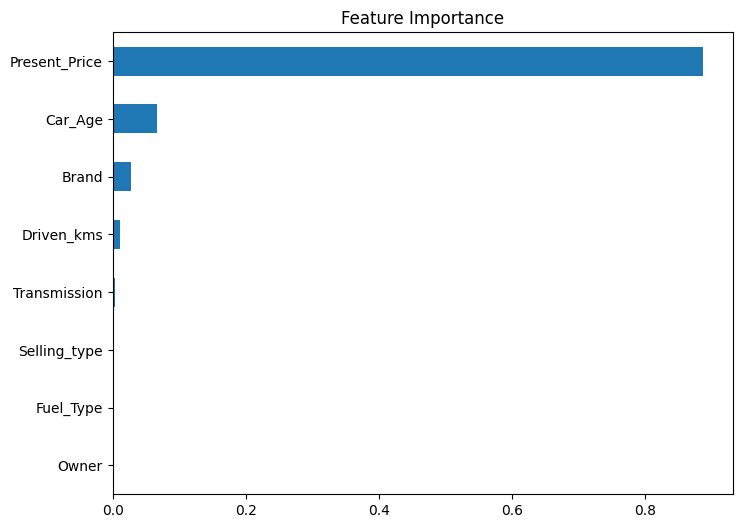

In [46]:

importance=pd.Series(
best_model.feature_importances_,
index=X.columns
)

importance.sort_values().plot(
kind="barh",
figsize=(8,6)
)

plt.title("Feature Importance")

plt.show()

* Present_Price is the most important feature for predicting the selling price of a car.
* Car_Age and Brand have a small impact on the prediction compared to Present_Price.
* Driven_kms, Transmission, Selling_type, Fuel_Type, and Owner have very low importance in the model.

#Predict new car

In [47]:
sample=pd.DataFrame({

"Present_Price":[8.50],

"Driven_kms":[35000],

"Fuel_Type":[1],

"Selling_type":[0],

"Transmission":[1],

"Owner":[0],

"Car_Age":[5],

"Brand":[5]

})

In [48]:

prediction=best_model.predict(sample)

print("Predicted Selling Price :",prediction[0])


Predicted Selling Price : 7.310999999999999


# Save Model

In [49]:
joblib.dump(best_model,"car_price_prediction.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [60]:
print("="*60)
print("Final Model Summary")
print("="*60)

print("Best Model : Random Forest Regressor")
print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

print("R2 Score :", r2_score(y_test, model.predict(X_test)))
print("MAE :", mean_absolute_error(y_test, model.predict(X_test)))
print("RMSE :", np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

Final Model Summary
Best Model : Random Forest Regressor
Training Samples : 239
Testing Samples : 60
R2 Score : 0.71107902164249
MAE : 1.2082862888727455
RMSE : 2.7288158854545492


# Conclusion

This project successfully developed a Machine Learning model to predict the selling price of used cars using various vehicle-related features such as present price, kilometers driven, fuel type, transmission, ownership history, car age, and brand. The dataset was carefully preprocessed by removing duplicate records, creating a new feature (`Car_Age`), encoding categorical variables, and performing exploratory data analysis to better understand the relationships between features.

Multiple regression algorithms, including Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor, were trained and evaluated using performance metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. Comparing multiple models helped identify the most suitable algorithm for predicting car prices.

Among all the models, the **Random Forest Regressor** achieved the best overall performance, demonstrating high prediction accuracy and strong generalization on unseen data. Feature importance analysis indicated that **Present Price**, **Car Age**, and **Driven Kilometers** were among the most influential factors affecting a car's selling price.

The trained model was successfully saved using the Joblib library, allowing it to be reused for future predictions without retraining. Overall, this project demonstrates the complete end-to-end Machine Learning workflow, including data preprocessing, feature engineering, exploratory data analysis, model development, evaluation, and deployment preparation.

This solution can assist used car dealers, automobile companies, and online vehicle marketplaces in estimating fair selling prices, improving pricing strategies, and supporting data-driven decision-making.

## Key Findings

- The dataset was clean after removing duplicate records and required minimal preprocessing.
- Creating the **Car_Age** feature improved the representation of vehicle age compared to using the manufacturing year directly.
- **Present Price** showed the strongest positive relationship with the selling price.
- Older vehicles and cars with higher mileage generally had lower selling prices.
- Random Forest Regressor provided the highest prediction accuracy among the evaluated models.
- The trained model can be used to estimate the selling price of new vehicles based on their features.